# 🚀 Practice Day 20

**📅 Date:** 2026-10-01  
**📁 Category:** Phase 2 · SQL 기초(DuckDB) (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice fundamental SQL commands (SELECT, WHERE, GROUP BY, ORDER BY, COUNT/SUM/AVG) using DuckDB on a single table
  (DuckDB로 SELECT/WHERE/GROUP BY/ORDER BY와 집계함수 등 기본 SQL 명령어를 단일 테이블에 연습)
- Find which genres are most popular and which run overdue most often, plus how borrowing volume moves month to month
  (어떤 장르가 가장 인기 있고 연체가 잦은지, 월별 대출량은 어떻게 변화하는지 파악하기)

---
# 📂 Dataset

**Dataset Name:** Cedar Falls Public Library — Checkout Records (H1 2024) / Cedar Falls 공공도서관 — 대출 기록 (2024년 상반기)

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** A single table of 380 checkout records from Cedar Falls Public Library, covering January–June 2024 across 7 genres (Fiction, Mystery, Romance, Science Fiction, Biography, Children's, History). Includes checkout date, due date, actual return date, and an overdue flag. A couple of rows have no return_date — those are books not yet returned, not a data error. Otherwise clean — no missing values or duplicates — so the focus stays on core DuckDB SELECT/WHERE/GROUP BY/ORDER BY and aggregate functions.
(Cedar Falls 공공도서관의 2024년 1~6월 대출 기록 380건을 담은 단일 테이블입니다. 7개 장르(Fiction/Mystery/Romance/Science Fiction/Biography/Children's/History)에 걸쳐 있으며, 대출일·반납예정일·실제반납일·연체여부를 포함합니다. return_date가 비어있는 몇 건은 아직 반납되지 않은 대출을 의미합니다(데이터 오류 아님). 그 외에는 결측치·중복 없이 깨끗한 데이터로, DuckDB의 SELECT/WHERE/GROUP BY/ORDER BY와 집계함수 연습에 초점을 둡니다.)

## Dataset Preview

In [8]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

# --- Generate library checkout records (single table) ---
genres = ['Fiction', 'Mystery', 'Romance', 'Science Fiction', 'Biography', "Children's", 'History']
genre_overdue_p = {'Fiction': 0.18, 'Mystery': 0.15, 'Romance': 0.12, 'Science Fiction': 0.30,
                    'Biography': 0.22, "Children's": 0.06, 'History': 0.33}

adjectives = ['Silent', 'Hidden', 'Last', 'Forgotten', 'Golden', 'Distant', 'Broken', 'Quiet',
              'Restless', 'Endless', 'Secret', 'Winding', 'Autumn', 'Midnight', 'Scarlet']
nouns = ['Garden', 'River', 'Harbor', 'Kingdom', 'Journey', 'Letter', 'Orchard', 'Bridge',
         'Mountain', 'Lighthouse', 'Promise', 'Shadow', 'Voyage', 'Chronicle', 'Meadow']

rng = np.random.default_rng(7)
titles_by_genre = {}
for g in genres:
    n_titles = rng.integers(5, 8)
    picks = set()
    while len(picks) < n_titles:
        t = f"The {rng.choice(adjectives)} {rng.choice(nouns)}"
        picks.add(t)
    titles_by_genre[g] = list(picks)

n_checkouts = 380
member_ids = [f"M{str(i).zfill(4)}" for i in range(1, 151)]
genre_weights = [0.22, 0.16, 0.14, 0.12, 0.10, 0.14, 0.12]

checkout_dates = pd.to_datetime('2024-01-01') + pd.to_timedelta(
    np.random.randint(0, 181, size=n_checkouts), unit='D'
)

rows = []
as_of = pd.to_datetime('2024-07-15')
for i in range(n_checkouts):
    genre = np.random.choice(genres, p=genre_weights)
    title = np.random.choice(titles_by_genre[genre])
    member = np.random.choice(member_ids)
    co_date = checkout_dates[i]
    due_date = co_date + pd.Timedelta(days=21)

    p_over = genre_overdue_p[genre]
    still_out = due_date > as_of and np.random.random() < 0.35
    if still_out:
        return_date = pd.NaT
        is_overdue = due_date < as_of
    else:
        if np.random.random() < p_over:
            late_days = int(np.random.randint(1, 15))
            return_date = due_date + pd.Timedelta(days=late_days)
            is_overdue = True
        else:
            early_days = int(np.random.randint(0, 20))
            return_date = co_date + pd.Timedelta(days=max(1, 21 - early_days))
            is_overdue = False

    rows.append({
        'checkout_id': f'C{str(i+1).zfill(4)}',
        'member_id': member,
        'book_title': title,
        'genre': genre,
        'checkout_date': co_date,
        'due_date': due_date,
        'return_date': return_date,
        'is_overdue': is_overdue
    })

df = pd.DataFrame(rows).sort_values('checkout_date').reset_index(drop=True)

df.head(10)


,checkout_id,member_id,book_title,genre,checkout_date,due_date,return_date,is_overdue
0,C0123,M0040,The Scarlet Voyage,Romance,2024-01-01,2024-01-22,2024-01-12,False
1,C0019,M0012,The Hidden Garden,Science Fiction,2024-01-02,2024-01-23,2024-01-23,False
2,C0065,M0085,The Forgotten Garden,Fiction,2024-01-02,2024-01-23,2024-01-13,False
3,C0194,M0142,The Endless Promise,Fiction,2024-01-02,2024-01-23,2024-01-13,False
4,C0248,M0059,The Hidden Kingdom,History,2024-01-02,2024-01-23,2024-01-14,False
5,C0168,M0074,The Hidden Kingdom,History,2024-01-03,2024-01-24,2024-01-08,False
6,C0220,M0092,The Autumn Promise,History,2024-01-03,2024-01-24,2024-01-10,False
7,C0315,M0116,The Last Meadow,Biography,2024-01-04,2024-01-25,2024-02-06,True
8,C0069,M0132,The Silent River,Biography,2024-01-04,2024-01-25,2024-01-09,False
9,C0124,M0101,The Forgotten Voyage,Romance,2024-01-05,2024-01-26,2024-01-13,False


## Dataset Information

In [9]:
# Dataset Information
df.info()
print("\nShape:", df.shape)
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   checkout_id    380 non-null    str           
 1   member_id      380 non-null    str           
 2   book_title     380 non-null    str           
 3   genre          380 non-null    str           
 4   checkout_date  380 non-null    datetime64[us]
 5   due_date       380 non-null    datetime64[us]
 6   return_date    378 non-null    datetime64[us]
 7   is_overdue     380 non-null    bool          
dtypes: bool(1), datetime64[us](3), str(4)
memory usage: 21.3 KB

Shape: (380, 8)


,checkout_id,member_id,book_title,genre,checkout_date,due_date,return_date,is_overdue
count,380,380,380,380,380,380,378,380
unique,380,142,42,7,NaN,NaN,NaN,2
top,C0123,M0063,The Scarlet Orchard,Fiction,NaN,NaN,NaN,False
freq,1,7,28,89,NaN,NaN,NaN,314
mean,NaN,NaN,NaN,NaN,2024-04-01 20:24:00,2024-04-22 20:24:00,2024-04-15 20:15:14.285714,NaN
min,NaN,NaN,NaN,NaN,2024-01-01 00:00:00,2024-01-22 00:00:00,2024-01-08 00:00:00,NaN
25%,NaN,NaN,NaN,NaN,2024-02-17 00:00:00,2024-03-09 00:00:00,2024-02-29 06:00:00,NaN
50%,NaN,NaN,NaN,NaN,2024-04-06 12:00:00,2024-04-27 12:00:00,2024-04-21 00:00:00,NaN
75%,NaN,NaN,NaN,NaN,2024-05-15 00:00:00,2024-06-05 00:00:00,2024-05-29 00:00:00,NaN
max,NaN,NaN,NaN,NaN,2024-06-29 00:00:00,2024-07-20 00:00:00,2024-07-20 00:00:00,NaN


---
# ❓ Business Questions

1. **(Analysis)** Which genre has been checked out the most, and which the least?
   (어떤 장르가 가장 많이/적게 대출되었는가?)
2. **(Analysis)** Which genre has the highest overdue rate, and which has the lowest?
   (연체 비율이 가장 높은/낮은 장르는?)
3. **(Analysis)** How does the number of checkouts change from month to month over the first half of the year?
   (상반기 동안 월별 대출 건수는 어떻게 변화하는가?)
4. **(Visualization)** Compare total checkout counts across all seven genres.
   (7개 장르의 대출건수를 비교하면?)
5. **(Visualization)** Show how monthly checkout volume moves across the six-month period.
   (6개월간 월별 대출량 추이는?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `isnull`, `dtypes`
  (결측·타입 확인)
- [x] SQL — DuckDB `GROUP BY`, `COUNT`, `SUM`, `ROUND`, `strftime`, `LAG`
  (그룹별 집계, 비율, 월 변환, 전월 대비 변화)
- [x] Matplotlib — `plt.subplots`
  (그림과 축)
- [x] Other: Seaborn — `sns.barplot`, `sns.lineplot`
  (가로 막대, 선 그래프)


---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — `return_date` 2 (books not yet returned), every other column 0
  (return_date 2건은 아직 반납되지 않은 대출. 나머지 컬럼 결측 0)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — dates are datetime, `is_overdue` is bool, ids and text are str; no fix needed
  (날짜는 datetime, is_overdue는 bool, 아이디와 텍스트는 문자열. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [10]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
checkout_id      0
member_id        0
book_title       0
genre            0
checkout_date    0
due_date         0
return_date      2
is_overdue       0
dtype: int64

Duplicate rows: 0

Dtypes
checkout_id                 str
member_id                   str
book_title                  str
genre                       str
checkout_date    datetime64[us]
due_date         datetime64[us]
return_date      datetime64[us]
is_overdue                 bool
dtype: object

Column names
['checkout_id', 'member_id', 'book_title', 'genre', 'checkout_date', 'due_date', 'return_date', 'is_overdue']

Text columns — unique counts
checkout_id    380
member_id      142
book_title      42
genre            7
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** Which genre has been checked out the most, and which the least? (어떤 장르가 가장 많이/적게 대출되었는가?)

**Result:** **Fiction** was checked out the most (**89**), and **History** the least (**36**).
(가장 많이 대출된 장르는 Fiction(89건), 가장 적은 장르는 History(36건))

**Insight:** Fiction is well ahead of the next genre, Science Fiction (**60**). History (**36**) and Biography (**37**) are nearly tied at the bottom.
(Fiction은 다음 순위인 Science Fiction(60건)보다 많이 앞서 있음. History(36건)와 Biography(37건)는 맨 아래에서 거의 같음)

In [16]:
# Question 1 (DuckDB): checkout count by genre - most / least borrowed

import duckdb

duckdb.sql("""
    SELECT genre, COUNT(*) AS checkout_count 
    FROM df 
    GROUP BY genre 
    ORDER BY checkout_count DESC
""").df()


,genre,checkout_count
0,Fiction,89
1,Science Fiction,60
2,Mystery,57
3,Children's,55
4,Romance,46
5,Biography,37
6,History,36


## Question 2

**Question:** Which genre has the highest overdue rate, and which has the lowest? (연체 비율이 가장 높은/낮은 장르는?)

**Result:** **Science Fiction** has the highest overdue rate (**26.67%**, 16 of 60), and **Children's** the lowest (**5.45%**, 3 of 55).
(연체 비율이 가장 높은 장르는 Science Fiction(26.67%, 60건 중 16건), 가장 낮은 장르는 Children's(5.45%, 55건 중 3건))

**Insight:** The most borrowed genre is not the most overdue. Fiction has the most overdue checkouts (**17**) but its rate is **19.10%**, below Science Fiction. Children's is borrowed often (**55**) and still has the lowest rate.
(대출이 가장 많은 장르가 연체 비율도 가장 높은 것은 아님. Fiction은 연체 건수가 가장 많지만(17건) 비율은 19.10%로 Science Fiction보다 낮음. Children's는 대출이 55건으로 많은데 비율은 가장 낮음)

In [19]:
# Question 2 (DuckDB): overdue rate by genre

duckdb.sql("""
    SELECT genre, COUNT(*) AS total, SUM(is_overdue) AS overdue_count, ROUND(SUM(is_overdue) * 100.0 / COUNT(*), 2) AS overdue_rate
    FROM df
    GROUP BY genre
    ORDER BY overdue_rate DESC
""").df()


,genre,total,overdue_count,overdue_rate
0,Science Fiction,60,16.0,26.67
1,History,36,8.0,22.22
2,Mystery,57,11.0,19.30
3,Fiction,89,17.0,19.10
4,Biography,37,7.0,18.92
5,Romance,46,4.0,8.70
6,Children's,55,3.0,5.45


## Question 3

**Question:** How does the number of checkouts change from month to month over the first half of the year? (상반기 월별 대출 건수 변화는?)

**Result:** Checkouts were **61** in January, **67** in February (**+6**), **47** in March (**-20**), **68** in April (**+21**), **80** in May (**+12**), and **57** in June (**-23**). January has no change value, because there is no previous month.
(1월 61건, 2월 67건(+6), 3월 47건(-20), 4월 68건(+21), 5월 80건(+12), 6월 57건(-23). 1월은 이전 달이 없어 변화량이 비어 있음)

**Insight:** The count does not rise steadily. It drops in March and again in June, and the high point is May (**80**).
(건수가 계속 늘지는 않음. 3월과 6월에 줄고, 가장 많은 달은 5월(80건))

In [23]:
# Question 3 (DuckDB): monthly checkout trend

duckdb.sql("""
    SELECT strftime(checkout_date, '%Y-%m') AS month, COUNT(*) AS checkouts, COUNT(*) - LAG(COUNT(*)) OVER (ORDER BY month) AS change
    FROM df 
    GROUP BY month 
    ORDER BY month
""").df()


,month,checkouts,change
0,2024-01,61,<NA>
1,2024-02,67,6
2,2024-03,47,-20
3,2024-04,68,21
4,2024-05,80,12
5,2024-06,57,-23


---
# 📈 Visualization

**Chart 1:** Bar chart — total checkouts by genre (막대그래프: 장르별 대출건수)

*Interpretation:* Fiction is the longest bar (about **89**). Science Fiction, Mystery, and Children's sit close together (about **60**, **57**, and **55**). History is the shortest (about **36**), just under Biography.
(Fiction 막대가 가장 김(약 89). Science Fiction, Mystery, Children's는 서로 가까움(약 60, 57, 55). History가 가장 짧고(약 36) Biography 바로 아래)

---

**Chart 2:** Line chart — monthly checkout volume (선그래프: 월별 대출량 추이)

*Interpretation:* The line rises from January to February, drops to the low point in March (about **47**), climbs to the peak in May (**80**), then falls in June (about **57**).
(선은 1월에서 2월로 오르고, 3월에 가장 낮아지며(약 47), 5월에 정점(80)을 찍은 뒤 6월에 내려감(약 57))

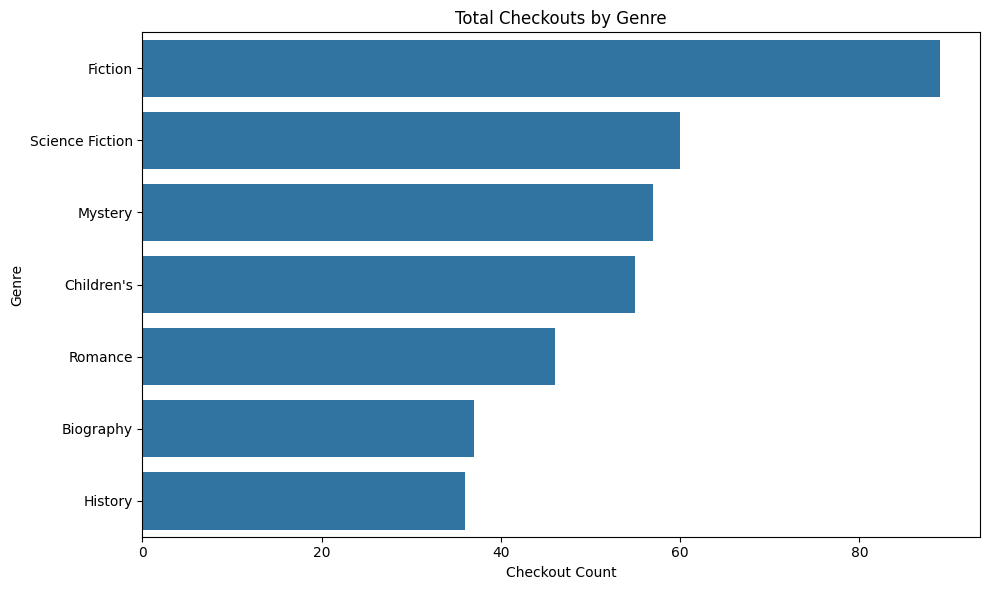

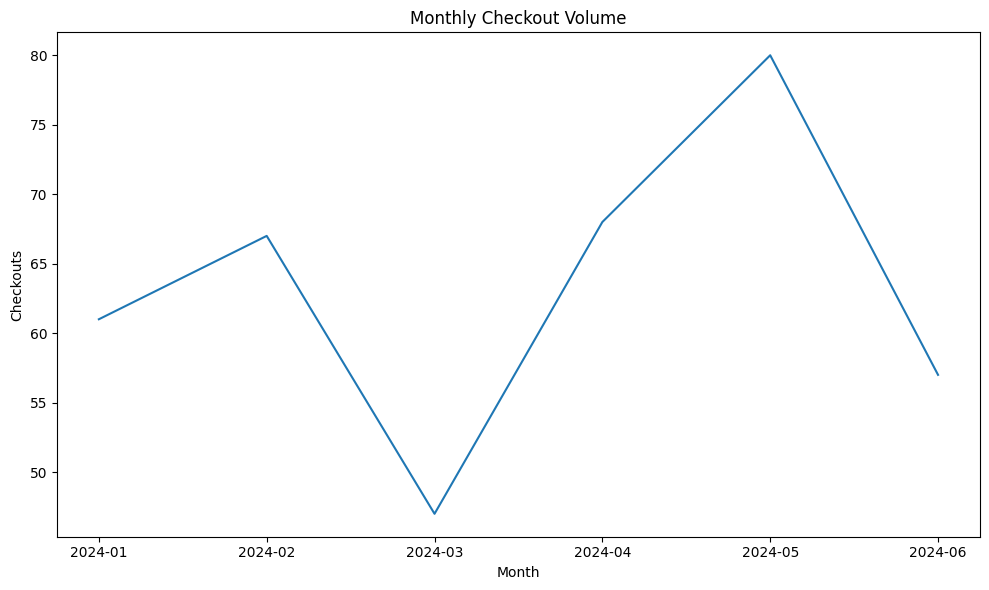

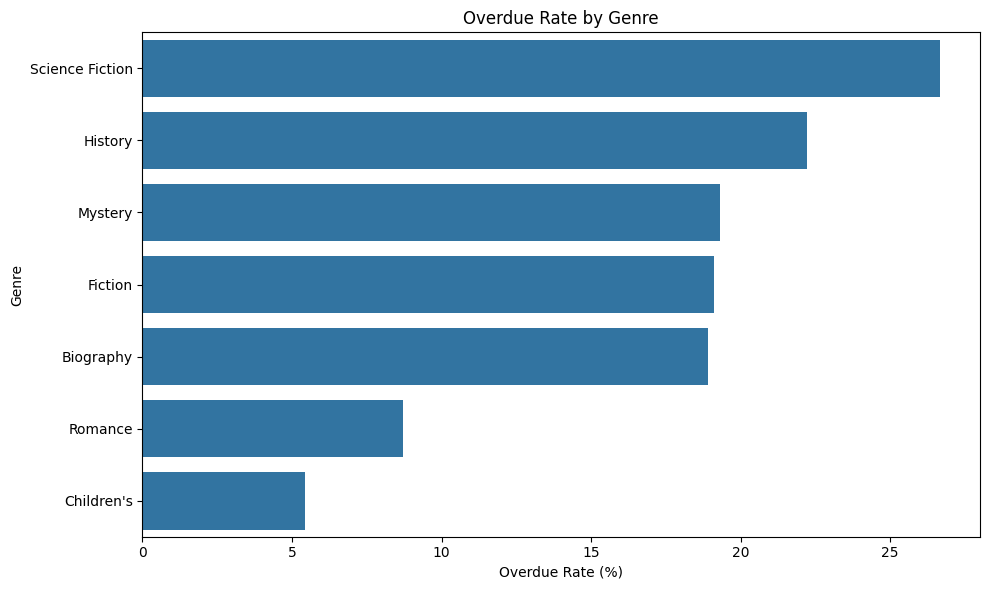

In [28]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: total checkout count by genre (bar)
data1 = duckdb.sql("""
    SELECT genre, COUNT(*) AS checkout_count 
    FROM df 
    GROUP BY genre 
    ORDER BY checkout_count DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='checkout_count', y='genre', data=data1, ax=ax)
ax.set_title('Total Checkouts by Genre')
ax.set_xlabel('Checkout Count')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()


# Chart 2: monthly checkout volume (line)

data2 = duckdb.sql("""
    SELECT strftime(checkout_date, '%Y-%m') AS month, COUNT(*) AS checkouts, COUNT(*) - LAG(COUNT(*)) OVER (ORDER BY month) AS change
    FROM df 
    GROUP BY month 
    ORDER BY month
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x='month', y='checkouts', data=data2, ax=ax)
ax.set_title('Monthly Checkout Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Checkouts')
plt.tight_layout()
plt.show()

# Chart 3: overdue rate by genre (bar)

data3 = duckdb.sql("""
    SELECT genre, COUNT(*) AS total, SUM(is_overdue) AS overdue_count, ROUND(SUM(is_overdue) * 100.0 / COUNT(*), 2) AS overdue_rate
    FROM df
    GROUP BY genre
    ORDER BY overdue_rate DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='overdue_rate', y='genre', data=data3, ax=ax)
ax.set_title('Overdue Rate by Genre')
ax.set_xlabel('Overdue Rate (%)')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

---
# 💼 Business Insights
**What did I discover?**

- Fiction is the most borrowed genre (**89** checkouts) and History is the least (**36**).
  (Fiction이 가장 많이 대출되고(89건) History가 가장 적음(36건))
- Science Fiction has the highest overdue rate (**26.67%**) and Children's the lowest (**5.45%**), even though Children's is borrowed often.
  (연체 비율은 Science Fiction이 가장 높고(26.67%) Children's가 가장 낮음(5.45%). Children's는 대출 건수는 많음)
- Monthly checkouts peak in May (**80**) and dip in March (**47**) and June (**57**).
  (월별 대출은 5월이 정점(80건)이고 3월(47건)과 6월(57건)에 줄어듦)
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Keep Fiction well stocked, because it accounts for the most checkouts (**89**).
   (Fiction 도서를 충분히 갖춰 두기. 대출이 가장 많기 때문(89건))
2. Send a due-date reminder for Science Fiction and History first, because their overdue rates are the highest (**26.67%** and **22.22%**).
   (Science Fiction과 History에 반납 예정 알림을 먼저 보내기. 연체 비율이 가장 높기 때문(26.67%, 22.22%))
3. Plan extra desk coverage for May, the busiest month (**80** checkouts), and expect quieter weeks in March and June.
   (가장 바쁜 5월(80건)에 데스크 인력을 더 두고, 3월과 6월은 한산할 수 있다고 보기)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I first counted overdue checkouts only. A higher count is not a higher rate, so I added `overdue_rate` as `SUM(is_overdue) * 100.0 / COUNT(*)`.
  (처음에는 연체 건수만 셈. 건수가 많다고 비율이 높은 것은 아니라서 overdue_rate를 SUM(is_overdue) * 100.0 / COUNT(*)로 추가)
- I sorted by the overdue count at first. The question asks for the rate, so the sort has to be `ORDER BY overdue_rate DESC`.
  (처음에는 연체 건수로 정렬함. 질문이 비율이므로 ORDER BY overdue_rate DESC로 정렬해야 함)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- `GROUP BY` with `COUNT` and `SUM` answers "how many" per group. Dividing the sum by the count, with `100.0`, gives the rate as a percent.
  (GROUP BY와 COUNT, SUM은 그룹별 건수를 알려 줌. 합계를 건수로 나누고 100.0을 곱하면 퍼센트 비율이 됨)
- `strftime(checkout_date, '%Y-%m')` turns a date into a month, so the monthly count can be grouped.
  (strftime(checkout_date, '%Y-%m')은 날짜를 월로 바꿔서 월별 건수를 묶을 수 있음)
- `LAG(COUNT(*)) OVER (ORDER BY month)` is the previous month's count. January is empty because there is no month before it.
  (LAG(COUNT(*)) OVER (ORDER BY month)는 전월 건수. 1월은 이전 달이 없어 비어 있음)
  

---
# 🧠 Reflection

**What was difficult?**
Telling the overdue count apart from the overdue rate.
(연체 건수와 연체 비율을 구분하는 것)

**Why?**
A genre can have more late books just because it is borrowed more often.
(대출이 많아서 연체 건수만 많을 수 있음)

**How did I solve it?**
Added `overdue_rate` in the same `SELECT` and sorted by that column.
(같은 SELECT에 overdue_rate를 넣고 그 열로 정렬)

**What would I do differently next time?**
Decide whether the question asks for a count or a rate before writing the `ORDER BY`.
(ORDER BY를 쓰기 전에 질문이 건수인지 비율인지 먼저 정하기)



---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
`GROUP BY`, `COUNT`, and `SUM` are clear. Turning a count into a rate needed help.  
(GROUP BY, COUNT, SUM은 이해. 건수를 비율로 바꾸는 것은 도움 필요)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★☆☆☆☆☆  
The overdue rate was the hardest.  
(연체 비율이 제일 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 21 — Table merge / join (Round 2/5)
  (테이블 병합(merge/join) 복습)
  